**Imported Required Libraries**

In [ ]:
import pandas as pd
import numpy as np

**1. Load IMDb files**

In [ ]:

# Load IMDb basics
imdb_basics = pd.read_csv(
    "/content/title.basics.csv",
    low_memory=False,
    usecols=["tconst", "titleType", "primaryTitle", "startYear", "runtimeMinutes", "genres"]
)
# Load IMDb ratings
imdb_ratings = pd.read_csv(
    "/content/title.ratings.csv",
    low_memory=False
)

**2. Clean IMDb basics and keep only movies**

In [ ]:
imdb_basics = imdb_basics[imdb_basics["titleType"] == "movie"].copy()

imdb_basics = imdb_basics[imdb_basics["startYear"].astype(str).str.isnumeric()]
imdb_basics["startYear"] = imdb_basics["startYear"].astype(int)

imdb_basics = imdb_basics[imdb_basics["runtimeMinutes"].astype(str).str.isnumeric()]
imdb_basics["runtimeMinutes"] = imdb_basics["runtimeMinutes"].astype(int)

imdb_basics["genres"] = imdb_basics["genres"].replace("\\N", np.nan)

**3.Merge IMDb basics + ratings**

In [ ]:
imdb_df = imdb_basics.merge(imdb_ratings, on="tconst", how="inner")
imdb_df = imdb_df[imdb_df["numVotes"] > 0].copy()

print("IMDb merged shape:", imdb_df.shape)
imdb_df.head()

IMDb merged shape: (138792, 8)


,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes
0,tt0000009,movie,Miss Jerry,1894,45,Romance,5.3,235
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,1897,100,"Documentary,News,Sport",5.3,593
2,tt0000502,movie,Bohemios,1905,100,NaN,3.5,26
3,tt0000574,movie,The Story of the Kelly Gang,1906,70,"Action,Adventure,Biography",6.0,1054
4,tt0000591,movie,The Prodigal Son,1907,90,Drama,4.9,38


**Load MovieLens files**

In [ ]:
ml_ratings = pd.read_csv("/content/ratings.csv")
ml_links = pd.read_csv("/content/links.csv")
ml_movies = pd.read_csv("/content/movies.csv")

**Prepare MovieLens IMDb key**

In [ ]:
ml_links["imdbId"] = ml_links["imdbId"].astype(str).str.strip()
ml_links["tconst"] = "tt" + ml_links["imdbId"].str.zfill(7)

ml_links.head()

,movieId,imdbId,tmdbId,tconst
0,1,114709,862.0,tt0114709
1,2,113497,8844.0,tt0113497
2,3,113228,15602.0,tt0113228
3,4,114885,31357.0,tt0114885
4,5,113041,11862.0,tt0113041


**Aggregate MovieLens ratings per movie**

In [ ]:
ml_agg = ml_ratings.groupby("movieId").agg(
    ml_rating_count=("rating", "count"),
    ml_avg_rating=("rating", "mean")
).reset_index()

print("MovieLens aggregated shape:", ml_agg.shape)
ml_agg.head()

MovieLens aggregated shape: (84432, 3)


,movieId,ml_rating_count,ml_avg_rating
0,1,68997,3.897438
1,2,28904,3.275758
2,3,13134,3.139447
3,4,2806,2.845331
4,5,13154,3.059602


**Timestamp based feature**

In [ ]:
ml_ratings["timestamp"] = pd.to_datetime(ml_ratings["timestamp"], unit="s", errors="coerce")

ml_time = ml_ratings.groupby("movieId").agg(
    first_rating_time=("timestamp", "min"),
    last_rating_time=("timestamp", "max")
).reset_index()

ml_agg = ml_agg.merge(ml_time, on="movieId", how="left")
ml_agg.head()

,movieId,ml_rating_count,ml_avg_rating,first_rating_time,last_rating_time
0,1,68997,3.897438,1996-01-29 00:00:00,2023-10-12 21:09:09
1,2,28904,3.275758,1996-01-29 00:00:00,2023-10-11 18:26:58
2,3,13134,3.139447,1996-02-01 14:33:48,2023-10-05 01:56:16
3,4,2806,2.845331,1996-02-01 14:33:45,2023-09-16 01:16:54
4,5,13154,3.059602,1996-02-01 14:33:44,2023-09-20 00:47:43


**Merge MovieLens links + aggregated ratings**

In [ ]:
ml_df = ml_links.merge(ml_agg, on="movieId", how="inner")
print("MovieLens merged shape:", ml_df.shape)
ml_df.head()

MovieLens merged shape: (84432, 8)


,movieId,imdbId,tmdbId,tconst,ml_rating_count,ml_avg_rating,first_rating_time,last_rating_time
0,1,114709,862.0,tt0114709,68997,3.897438,1996-01-29 00:00:00,2023-10-12 21:09:09
1,2,113497,8844.0,tt0113497,28904,3.275758,1996-01-29 00:00:00,2023-10-11 18:26:58
2,3,113228,15602.0,tt0113228,13134,3.139447,1996-02-01 14:33:48,2023-10-05 01:56:16
3,4,114885,31357.0,tt0114885,2806,2.845331,1996-02-01 14:33:45,2023-09-16 01:16:54
4,5,113041,11862.0,tt0113041,13154,3.059602,1996-02-01 14:33:44,2023-09-20 00:47:43


**Merge MovieLens with IMDb using tconst**

In [ ]:
imdb_ml_df = imdb_df.merge(ml_df, on="tconst", how="left")
print("IMDb + MovieLens shape:", imdb_ml_df.shape)
imdb_ml_df.head()

IMDb + MovieLens shape: (138792, 15)


,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes,movieId,imdbId,tmdbId,ml_rating_count,ml_avg_rating,first_rating_time,last_rating_time
0,tt0000009,movie,Miss Jerry,1894,45,Romance,5.3,235,NaN,NaN,NaN,NaN,NaN,NaT,NaT
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,1897,100,"Documentary,News,Sport",5.3,593,NaN,NaN,NaN,NaN,NaN,NaT,NaT
2,tt0000502,movie,Bohemios,1905,100,NaN,3.5,26,NaN,NaN,NaN,NaN,NaN,NaT,NaT
3,tt0000574,movie,The Story of the Kelly Gang,1906,70,"Action,Adventure,Biography",6.0,1054,170573.0,574,20105.0,9.0,2.5,2017-03-31 06:18:41,2022-12-30 09:49:05
4,tt0000591,movie,The Prodigal Son,1907,90,Drama,4.9,38,NaN,NaN,NaN,NaN,NaN,NaT,NaT


**Load TMDB file**

In [ ]:
tmdb_movies = pd.read_csv("/content/TMDB_movies.csv", low_memory=False)
print(tmdb_movies.columns.tolist())

['id', 'title', 'original_title', 'original_language', 'release_date', 'runtime', 'status', 'adult', 'budget', 'revenue', 'popularity', 'vote_average', 'vote_count', 'imdb_id', 'homepage', 'tagline', 'overview']


**Keep useful TMDB columns and clean IDs**


This assumes your TMDB file has these columns. If column names differ slightly, print the columns and adjust.

In [ ]:
tmdb_keep = ["id", "imdb_id", "budget", "popularity", "release_date", "original_language"]

tmdb_movies = tmdb_movies[tmdb_keep].copy()
tmdb_movies = tmdb_movies.dropna(subset=["imdb_id"])

tmdb_movies["imdb_id"] = tmdb_movies["imdb_id"].astype(str).str.strip()
tmdb_movies["budget"] = pd.to_numeric(tmdb_movies["budget"], errors="coerce")
tmdb_movies["popularity"] = pd.to_numeric(tmdb_movies["popularity"], errors="coerce")
tmdb_movies["release_date"] = pd.to_datetime(tmdb_movies["release_date"], errors="coerce")
tmdb_movies["release_month"] = tmdb_movies["release_date"].dt.month

tmdb_movies.head()

,id,imdb_id,budget,popularity,release_date,original_language,release_month
0,3924,tt0029927,0,2.1000,1938-11-30,en,11.0
1,8773,tt0055747,0,0.4517,1962-06-22,fr,6.0
3,31975,tt1656746,0,0.0256,2010-01-05,en,1.0
4,2,tt0094675,0,4.9747,1988-10-21,fi,10.0
5,3,tt0092149,0,6.5246,1986-10-17,fi,10.0


**Merge TMDB with the combined dataset**

In [ ]:
final_df = imdb_ml_df.merge(
    tmdb_movies,
    left_on="tconst",
    right_on="imdb_id",
    how="left"
)

print("Final merged shape:", final_df.shape)
final_df.head()

Final merged shape: (138792, 22)


,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes,movieId,imdbId,...,ml_avg_rating,first_rating_time,last_rating_time,id,imdb_id,budget,popularity,release_date,original_language,release_month
0,tt0000009,movie,Miss Jerry,1894,45,Romance,5.3,235,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,1897,100,"Documentary,News,Sport",5.3,593,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN
2,tt0000502,movie,Bohemios,1905,100,NaN,3.5,26,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN
3,tt0000574,movie,The Story of the Kelly Gang,1906,70,"Action,Adventure,Biography",6.0,1054,170573.0,574,...,2.5,2017-03-31 06:18:41,2022-12-30 09:49:05,NaN,NaN,NaN,NaN,NaT,NaN,NaN
4,tt0000591,movie,The Prodigal Son,1907,90,Drama,4.9,38,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN


**Check how the merged dataset looks**

In [ ]:
print(final_df.shape)
final_df.info()
final_df.head(10)

(138792, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138792 entries, 0 to 138791
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   tconst             138792 non-null  object        
 1   titleType          138792 non-null  object        
 2   primaryTitle       138792 non-null  object        
 3   startYear          138792 non-null  int64         
 4   runtimeMinutes     138792 non-null  int64         
 5   genres             134852 non-null  object        
 6   averageRating      138792 non-null  float64       
 7   numVotes           138792 non-null  int64         
 8   movieId            36257 non-null   float64       
 9   imdbId             36257 non-null   object        
 10  tmdbId             36228 non-null   float64       
 11  ml_rating_count    36257 non-null   float64       
 12  ml_avg_rating      36257 non-null   float64       
 13  first_rating_time  36257 non-nu

,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes,movieId,imdbId,...,ml_avg_rating,first_rating_time,last_rating_time,id,imdb_id,budget,popularity,release_date,original_language,release_month
0,tt0000009,movie,Miss Jerry,1894,45,Romance,5.3,235,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,1897,100,"Documentary,News,Sport",5.3,593,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN
2,tt0000502,movie,Bohemios,1905,100,NaN,3.5,26,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN
3,tt0000574,movie,The Story of the Kelly Gang,1906,70,"Action,Adventure,Biography",6.0,1054,170573.0,574,...,2.5,2017-03-31 06:18:41,2022-12-30 09:49:05,NaN,NaN,NaN,NaN,NaT,NaN,NaN
4,tt0000591,movie,The Prodigal Son,1907,90,Drama,4.9,38,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN
5,tt0000679,movie,The Fairylogue and Radio-Plays,1908,120,"Adventure,Fantasy",5.0,84,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN
6,tt0000941,movie,Locura de amor,1909,45,Drama,4.2,38,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN
7,tt0001184,movie,Don Juan de Serrallonga,1910,58,"Adventure,Drama",3.2,28,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN
8,tt0001285,movie,The Life of Moses,1909,50,"Biography,Drama,Family",5.1,82,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN
9,tt0001498,movie,The Battle of Trafalgar,1911,51,War,7.6,22,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN


In [ ]:
df = final_df

In [ ]:
df.shape

(138792, 22)

In [ ]:
df.describe()

,startYear,runtimeMinutes,averageRating,numVotes,movieId,tmdbId,ml_rating_count,ml_avg_rating,first_rating_time,last_rating_time,id,budget,popularity,release_date,release_month
count,138792.000000,138792.000000,138792.000000,1.387920e+05,36257.000000,3.622800e+04,36257.000000,36257.000000,36257,36257,4329.000000,4.329000e+03,4329.000000,4329,4329.000000
mean,1976.315393,93.578809,6.050291,5.012471e+03,111202.662962,8.582608e+04,742.388063,3.010361,2012-08-13 05:13:25.946768896,2021-10-14 11:14:43.031689984,4445.111342,1.643055e+07,3.177349,1987-07-21 12:09:28.814968832,6.958882
min,1894.000000,1.000000,1.000000,5.000000e+00,1.000000,2.000000e+00,1.000000,0.500000,1995-01-09 11:46:44,2002-02-12 03:57:29,2.000000,0.000000e+00,0.033600,1914-04-30 00:00:00,1.000000
25%,1960.000000,81.000000,5.300000,3.000000e+01,27485.000000,2.277850e+04,2.000000,2.607843,2006-11-09 00:49:02,2020-08-19 03:39:04,1684.000000,0.000000e+00,0.941200,1973-12-01 00:00:00,4.000000
50%,1980.000000,91.000000,6.200000,9.600000e+01,121126.000000,4.995300e+04,7.000000,3.071429,2015-06-07 07:51:49,2022-08-28 12:18:35,4141.000000,1.200000e+06,2.280800,1994-12-21 00:00:00,7.000000
75%,1997.000000,101.000000,6.800000,4.500000e+02,172015.000000,1.095608e+05,76.000000,3.500000,2018-07-12 17:38:34,2023-08-05 13:59:17,7220.000000,2.000000e+07,4.524500,2003-09-17 00:00:00,10.000000
max,2026.000000,5220.000000,9.800000,3.158671e+06,292755.000000,1.011667e+06,102929.000000,5.000000,2023-10-12 21:08:48,2023-10-13 02:14:11,9849.000000,3.000000e+08,71.686900,2017-04-01 00:00:00,12.000000
std,23.591221,30.104855,1.167143,4.753652e+04,82091.278000,9.943135e+04,3793.242947,0.721358,NaN,NaN,3160.741167,3.039919e+07,3.252088,NaN,3.489444


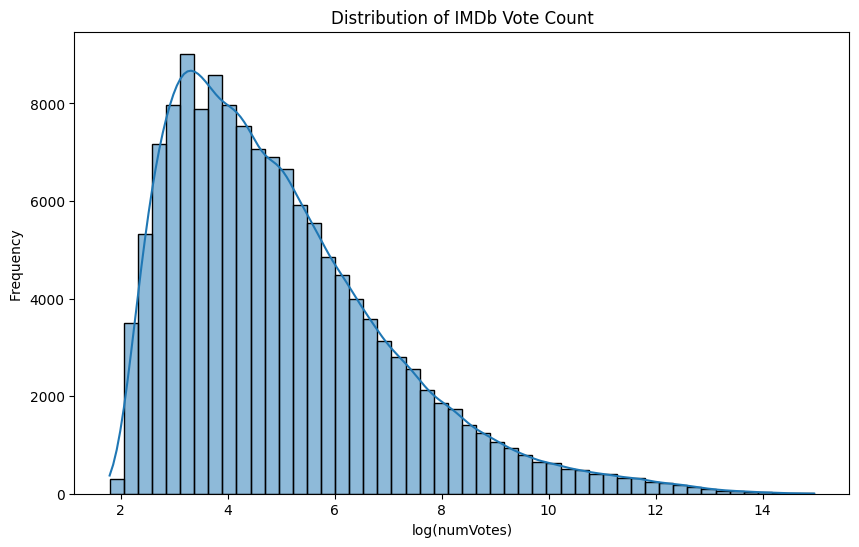

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# log-transformed version of numVotes for better visualization of skewness
df['log_numVotes_display'] = np.log1p(df['numVotes']) # log1p handles zero values gracefully

plt.figure(figsize=(10, 6))
sns.histplot(df['log_numVotes_display'], bins=50, kde=True)

plt.title("Distribution of IMDb Vote Count")
plt.xlabel("log(numVotes)")
plt.ylabel("Frequency ")
plt.show()

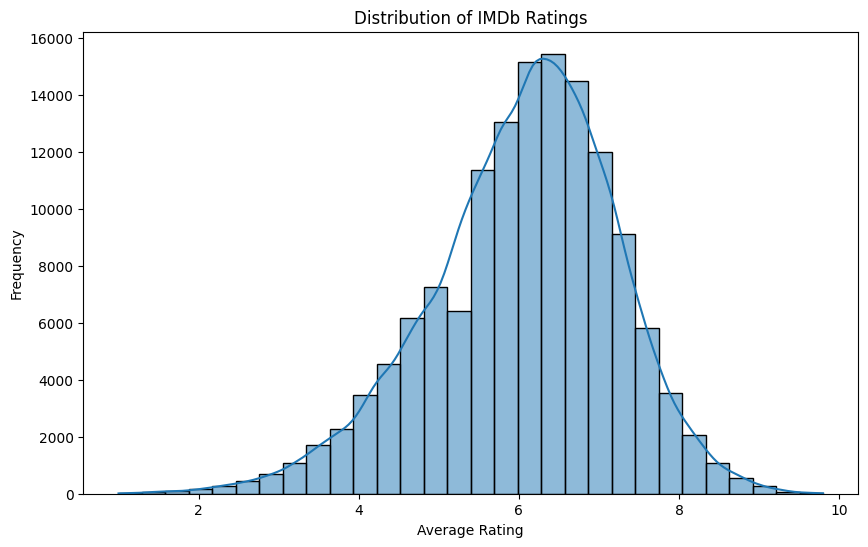

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df['averageRating'], bins=30, kde=True)
plt.title("Distribution of IMDb Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Frequency")
plt.show()

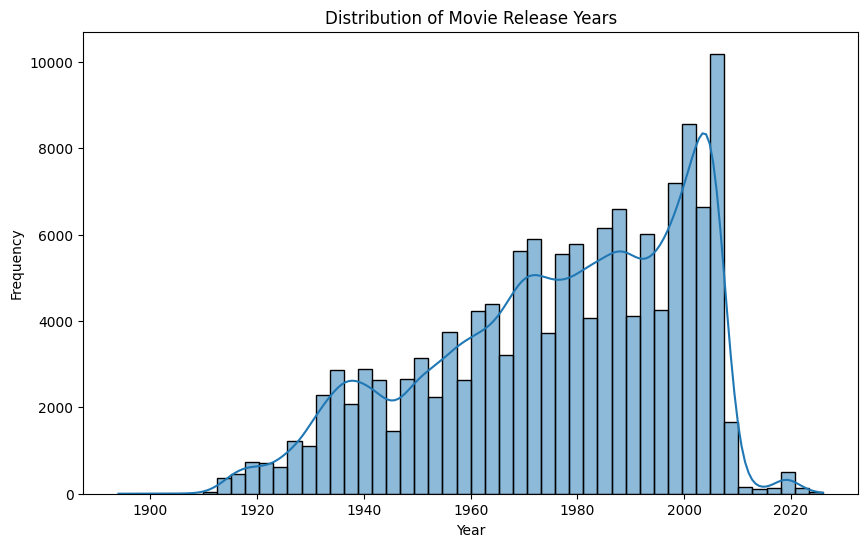

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df['startYear'], bins=50, kde=True)
plt.title("Distribution of Movie Release Years")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()

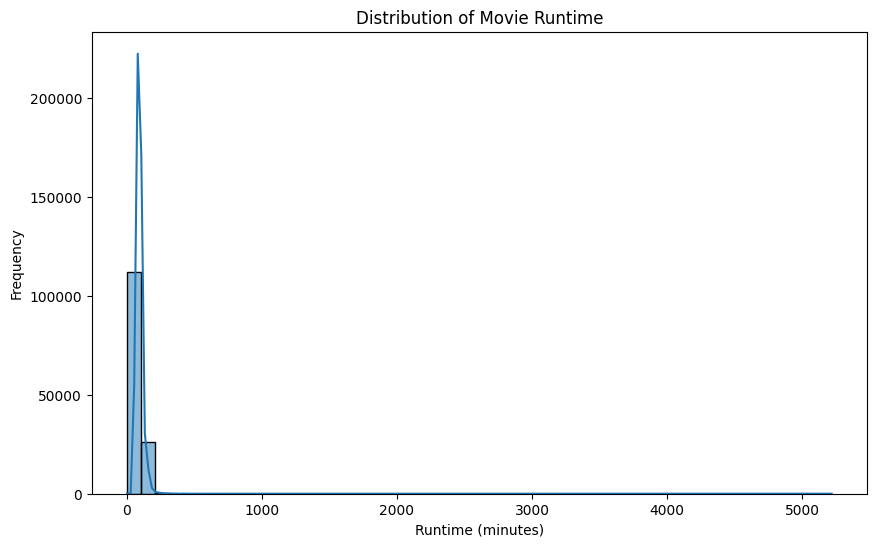

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df['runtimeMinutes'], bins=50, kde=True)
plt.title("Distribution of Movie Runtime")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
cols = ['averageRating','numVotes','ml_rating_count','ml_avg_rating']
print(df[cols].corr())

                 averageRating  numVotes  ml_rating_count  ml_avg_rating
averageRating         1.000000  0.102742         0.189041       0.590271
numVotes              0.102742  1.000000         0.877054       0.138744
ml_rating_count       0.189041  0.877054         1.000000       0.144464
ml_avg_rating         0.590271  0.138744         0.144464       1.000000


In [ ]:
df['runtimeMinutes'].describe()

,runtimeMinutes
count,138792.000000
mean,93.578809
std,30.104855
min,1.000000
25%,81.000000
50%,91.000000
75%,101.000000
max,5220.000000


In [ ]:
df[df['runtimeMinutes'] > 300][['primaryTitle','runtimeMinutes']].head(10)

,primaryTitle,runtimeMinutes
92,The Beloved Adventurer,450
119,The Hazards of Helen,1428
137,The Master Key,310
161,The Trey o' Hearts,310
187,The Broken Coin,440
229,The Goddess,310
313,Les Vampires,421
320,Who Pays?,360
421,Liberty,400
545,The Fatal Ring,400


In [ ]:
df[df['startYear'] > 2023][['primaryTitle','startYear']].head(10)

,primaryTitle,startYear
73751,Shyamchi Aai,2025
86469,The Perfect Shadow,2024
95573,Ek Hota Vidushak,2025
103489,Universal Groove,2024
110493,The Killer's Game,2024
114762,Specter's Rock,2026
115922,The Promise of Perfume,2024
125917,Nefarious,2024
126177,On Moral Grounds,2024
130935,The Twits,2025


In [ ]:
df[df['startYear'] > 2023][['primaryTitle','startYear']].head(10)

,primaryTitle,startYear
73751,Shyamchi Aai,2025
86469,The Perfect Shadow,2024
95573,Ek Hota Vidushak,2025
103489,Universal Groove,2024
110493,The Killer's Game,2024
114762,Specter's Rock,2026
115922,The Promise of Perfume,2024
125917,Nefarious,2024
126177,On Moral Grounds,2024
130935,The Twits,2025


In [ ]:
df['ml_rating_count'].isnull().sum()

np.int64(102535)

In [ ]:
df['ml_rating_count'].notnull().sum()

np.int64(36257)

In [ ]:
df_clean = df[df['startYear'] <= 2023]

In [ ]:
df_clean.shape

(138762, 23)

In [ ]:
df_clean = df_clean[(df_clean['runtimeMinutes'] >= 40) & (df_clean['runtimeMinutes'] <= 240)]

In [ ]:
df_clean.shape

(138451, 23)

In [ ]:
df_clean = df_clean[df_clean['ml_rating_count'].notnull()]

In [ ]:
df_clean.shape

(36188, 23)

In [ ]:
df_clean[['numVotes','ml_rating_count','popularity','budget']].skew()

,0
numVotes,13.376014
ml_rating_count,10.956787
popularity,4.180323
budget,2.723593


In [ ]:
df_clean['log_numVotes'] = np.log1p(df_clean['numVotes'])

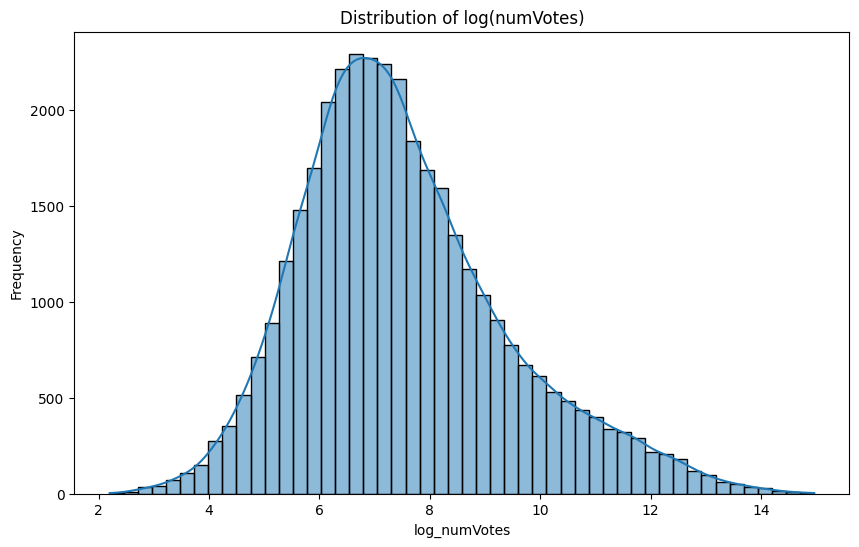

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df_clean['log_numVotes'], bins=50, kde=True)
plt.title("Distribution of log(numVotes)")
plt.xlabel("log_numVotes")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df_clean['log_ml_rating_count'] = np.log1p(df_clean['ml_rating_count'])

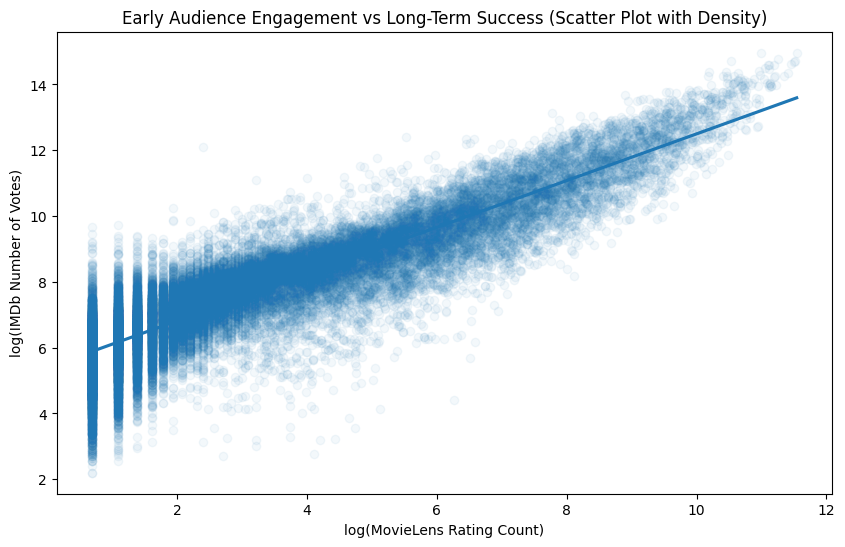

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.regplot(x='log_ml_rating_count', y='log_numVotes', data=df_clean, scatter_kws={'alpha':0.05})
plt.title("Early Audience Engagement vs Long-Term Success (Scatter Plot with Density)")
plt.xlabel("log(MovieLens Rating Count)")
plt.ylabel("log(IMDb Number of Votes)")
plt.show()

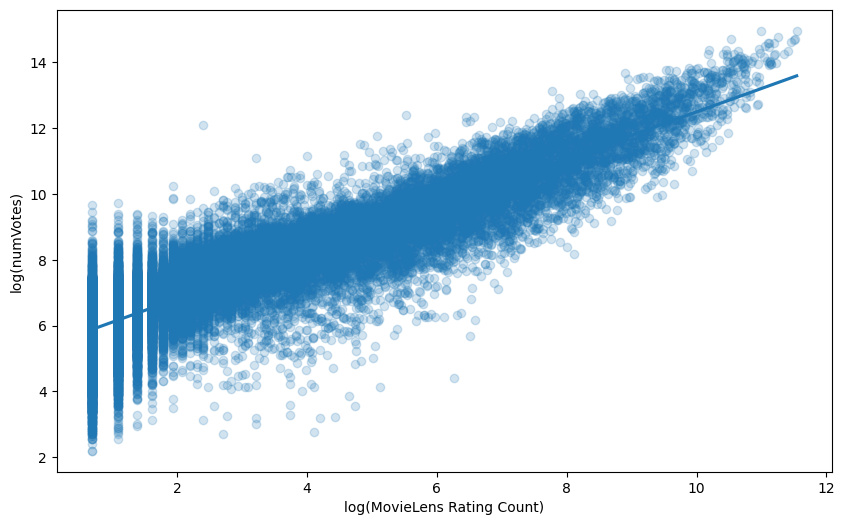

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='log_ml_rating_count', y='log_numVotes', data=df_clean, scatter_kws={'alpha':0.2})
plt.xlabel("log(MovieLens Rating Count)")
plt.ylabel("log(numVotes)")
plt.show()

In [ ]:
df_clean[['budget','popularity','original_language','genres']].isnull().sum()

,0
budget,32512
popularity,32512
original_language,32512
genres,34


In [ ]:
df_clean['genres'] = df_clean['genres'].fillna('Unknown')

In [ ]:
df_clean['genre_count'] = df_clean['genres'].str.split(',').apply(len)

In [ ]:
df_clean['genre_count'].describe()

,genre_count
count,36188.000000
mean,2.217061
std,0.792927
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,3.000000


In [ ]:
df_clean['log_ml_rating_count'] = np.log1p(df_clean['ml_rating_count'])
df_clean['log_budget'] = np.log1p(df_clean['budget'])
df_clean['log_popularity'] = np.log1p(df_clean['popularity'])

In [ ]:
df_clean[['log_ml_rating_count','log_budget','log_popularity']].describe()

,log_ml_rating_count,log_budget,log_popularity
count,36188.000000,3676.000000,3676.000000
mean,2.998351,10.645226,1.301561
std,2.394286,7.863072,0.626651
min,0.693147,0.000000,0.070458
25%,1.098612,0.000000,0.808104
50%,2.079442,15.201805,1.283029
75%,4.343805,17.034386,1.767018
max,11.541804,19.519293,4.286161


In [ ]:
df_clean['movie_age'] = 2023 - df_clean['startYear']

In [ ]:
df_clean[['startYear','movie_age']].head()

,startYear,movie_age
3,1906,117
23,1912,111
24,1911,112
27,1912,111
28,1919,104


In [ ]:
features = [
    'averageRating',
    'ml_avg_rating',
    'log_ml_rating_count',
    'runtimeMinutes',
    'genre_count',
    'movie_age'
]

X = df_clean[features]
y = df_clean['log_numVotes']

In [ ]:
print(X.shape)
print(y.shape)

(36188, 6)
(36188,)


In [ ]:
df_clean.head(30)

,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes,movieId,imdbId,...,release_date,original_language,release_month,log_numVotes_display,log_numVotes,log_ml_rating_count,genre_count,log_budget,log_popularity,movie_age
3,tt0000574,movie,The Story of the Kelly Gang,1906,70,"Action,Adventure,Biography",6.0,1054,170573.0,574,...,NaT,NaN,NaN,6.961296,6.961296,2.302585,3,NaN,NaN,117
23,tt0002101,movie,Cleopatra,1912,100,"Drama,History",5.1,666,170479.0,2101,...,NaT,NaN,NaN,6.502790,6.502790,1.609438,2,NaN,NaN,111
24,tt0002130,movie,Dante's Inferno,1911,71,"Adventure,Drama,Fantasy",7.0,4046,116578.0,2130,...,NaT,NaN,NaN,8.305731,8.305731,3.688879,3,NaN,NaN,112
27,tt0002199,movie,From the Manger to the Cross,1912,71,"Biography,Drama",5.9,702,288777.0,2199,...,NaT,NaN,NaN,6.555357,6.555357,0.693147,2,NaN,NaN,111
28,tt0002423,movie,Passion,1919,113,"Biography,Drama,Romance",6.7,1120,281404.0,2423,...,NaT,NaN,NaN,7.021976,7.021976,0.693147,3,NaN,NaN,104
29,tt0002445,movie,Quo Vadis?,1913,120,"Drama,History",6.1,520,271206.0,2445,...,NaT,NaN,NaN,6.255750,6.255750,0.693147,2,NaN,NaN,110
30,tt0002452,movie,The Independence of Romania,1912,120,"History,War",6.3,285,238018.0,2452,...,NaT,NaN,NaN,5.655992,5.655992,0.693147,2,NaN,NaN,111
31,tt0002461,movie,The Life and Death of King Richard III,1912,55,Drama,5.7,351,89323.0,2461,...,NaT,NaN,NaN,5.863631,5.863631,1.098612,1,NaN,NaN,111
40,tt0002646,movie,Atlantis,1913,121,Drama,6.5,523,197541.0,2646,...,NaT,NaN,NaN,6.261492,6.261492,1.386294,1,NaN,NaN,110
48,tt0002844,movie,FantÃ´mas: In the Shadow of the Guillotine,1913,54,"Crime,Drama",6.9,2709,100946.0,2844,...,NaT,NaN,NaN,7.904704,7.904704,3.332205,2,NaN,NaN,110


Final feature engineering for modeling

In [ ]:
import pandas as pd
import numpy as np

model_df = df_clean.copy()

# Target
model_df["log_numVotes"] = np.log1p(model_df["numVotes"])

# Budget transform
model_df["budget"] = pd.to_numeric(model_df["budget"], errors="coerce")
model_df["log_budget"] = np.log1p(model_df["budget"])

# Release month
model_df["release_date"] = pd.to_datetime(model_df["release_date"], errors="coerce")
model_df["release_month"] = model_df["release_date"].dt.month

# Primary genre from IMDb genres
model_df["genres"] = model_df["genres"].fillna("Unknown")
model_df["primary_genre"] = model_df["genres"].apply(
    lambda x: x.split(",")[0] if isinstance(x, str) and len(x) > 0 else "Unknown"
)

# Clean language
model_df["original_language"] = model_df["original_language"].fillna("unk")

# Keep only rows with target
model_df = model_df[model_df["log_numVotes"].notna()].copy()

print("Model dataset shape:", model_df.shape)
model_df.head()

Model dataset shape: (36188, 30)


,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes,movieId,imdbId,...,original_language,release_month,log_numVotes_display,log_numVotes,log_ml_rating_count,genre_count,log_budget,log_popularity,movie_age,primary_genre
3,tt0000574,movie,The Story of the Kelly Gang,1906,70,"Action,Adventure,Biography",6.0,1054,170573.0,574,...,unk,NaN,6.961296,6.961296,2.302585,3,NaN,NaN,117,Action
23,tt0002101,movie,Cleopatra,1912,100,"Drama,History",5.1,666,170479.0,2101,...,unk,NaN,6.502790,6.502790,1.609438,2,NaN,NaN,111,Drama
24,tt0002130,movie,Dante's Inferno,1911,71,"Adventure,Drama,Fantasy",7.0,4046,116578.0,2130,...,unk,NaN,8.305731,8.305731,3.688879,3,NaN,NaN,112,Adventure
27,tt0002199,movie,From the Manger to the Cross,1912,71,"Biography,Drama",5.9,702,288777.0,2199,...,unk,NaN,6.555357,6.555357,0.693147,2,NaN,NaN,111,Biography
28,tt0002423,movie,Passion,1919,113,"Biography,Drama,Romance",6.7,1120,281404.0,2423,...,unk,NaN,7.021976,7.021976,0.693147,3,NaN,NaN,104,Biography


Encode categorical columns

In [ ]:
model_df = pd.get_dummies(
    model_df,
    columns=["primary_genre", "original_language"],
    drop_first=True,
    dtype=float
)

Define feature groups for research question

In [ ]:
# Production-only features
prod_features = [
    "log_budget",
    "runtimeMinutes",
    "startYear",
    "release_month"
]

prod_features += [c for c in model_df.columns if c.startswith("primary_genre_")]
prod_features += [c for c in model_df.columns if c.startswith("original_language_")]

# Audience / early popularity features
aud_features = [
    "averageRating",
    "ml_rating_count",
    "ml_avg_rating",
    "popularity"
]

# Combined features
all_features = prod_features + aud_features

# Target
y = model_df["log_numVotes"]

print("Production features:", len(prod_features))
print("Audience features:", len(aud_features))
print("Combined features:", len(all_features))


Production features: 69
Audience features: 4
Combined features: 73


Fill missing values for modeling

In [ ]:
X_prod = model_df[prod_features].fillna(0)
X_aud  = model_df[aud_features].fillna(0)
X_all  = model_df[all_features].fillna(0)

Train and evaluate models

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_model(X, y, model, model_name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return {
        "Model": model_name,
        "RMSE": rmse,
        "R2": r2
    }


Ran all 6 models

In [ ]:
results = []

# Production-only
results.append(
    evaluate_model(
        X_prod, y,
        LinearRegression(),
        "Production Only - Linear Regression"
    )
)

results.append(
    evaluate_model(
        X_prod, y,
        RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
        "Production Only - Random Forest"
    )
)

# Audience-only
results.append(
    evaluate_model(
        X_aud, y,
        LinearRegression(),
        "Audience Only - Linear Regression"
    )
)

results.append(
    evaluate_model(
        X_aud, y,
        RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
        "Audience Only - Random Forest"
    )
)

# Combined
results.append(
    evaluate_model(
        X_all, y,
        LinearRegression(),
        "Combined - Linear Regression"
    )
)

results.append(
    evaluate_model(
        X_all, y,
        RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
        "Combined - Random Forest"
    )
)

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
results_df


,Model,RMSE,R2
5,Combined - Random Forest,0.709263,0.862988
3,Audience Only - Random Forest,0.856108,0.800382
4,Combined - Linear Regression,1.389466,0.474178
0,Production Only - Linear Regression,1.517482,0.372823
1,Production Only - Random Forest,1.613375,0.291053
2,Audience Only - Linear Regression,1.623184,0.282407


Plot model comparison

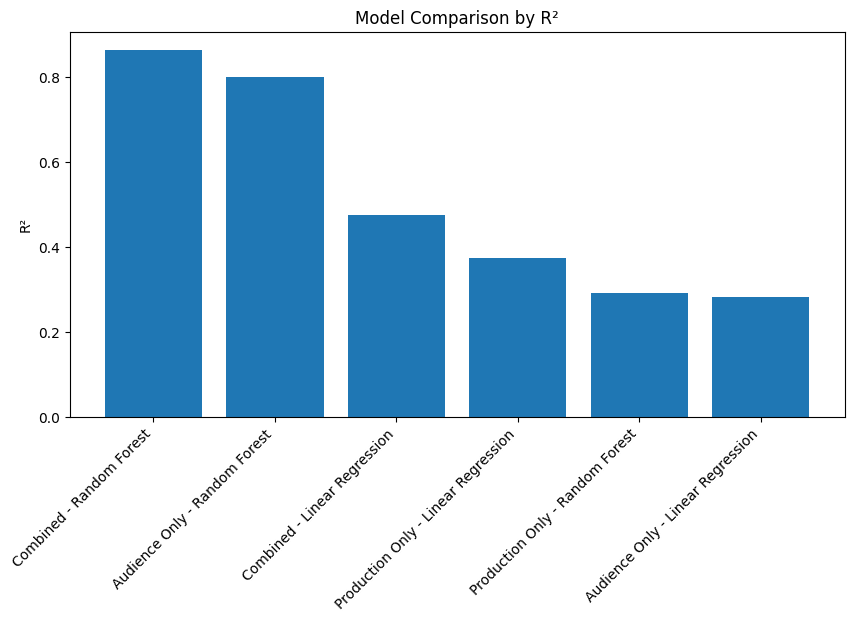

In [ ]:
import matplotlib.pyplot as plt

# R2 comparison
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["R2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("R²")
plt.title("Model Comparison by R²")
plt.show()


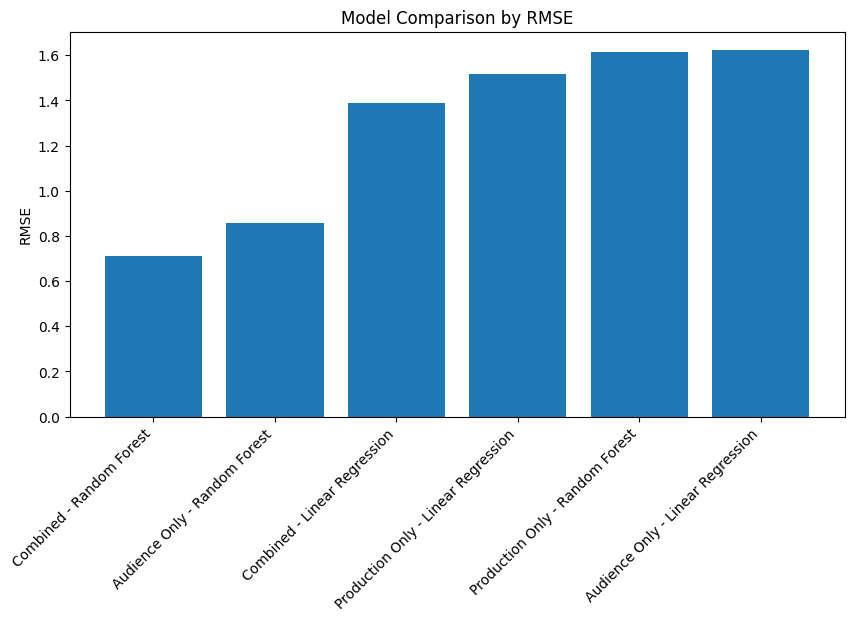

In [ ]:
# RMSE comparison
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Model Comparison by RMSE")
plt.show()

Feature importance for the best Random Forest

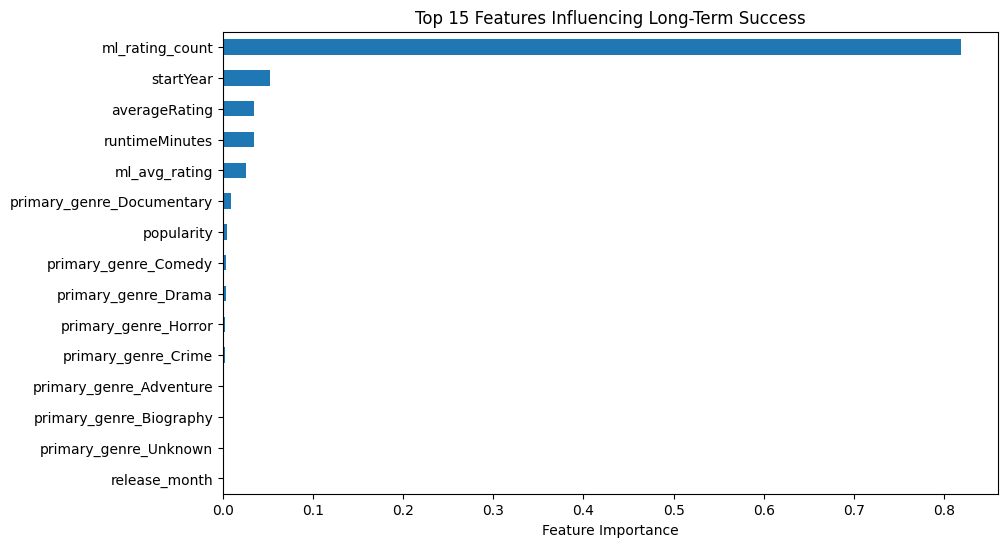

,0
ml_rating_count,0.818996
startYear,0.051669
averageRating,0.034937
runtimeMinutes,0.034491
ml_avg_rating,0.026057
primary_genre_Documentary,0.008963
popularity,0.004853
primary_genre_Comedy,0.003686
primary_genre_Drama,0.003444
primary_genre_Horror,0.001881


In [ ]:
# Train combined random forest again for feature importance
rf_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_final.fit(X_all, y)

importances = pd.Series(rf_final.feature_importances_, index=X_all.columns)
top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
top_importances.sort_values().plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("Top 15 Features Influencing Long-Term Success")
plt.show()

top_importances


Statistical Model Evaluation using OLS

In [ ]:
import statsmodels.api as sm

In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

def evaluate_ols_aic_bic(X, y, model_name):
    # Make a copy
    X = X.copy()
    y = y.copy()

    # Force everything to numeric
    X = X.apply(pd.to_numeric, errors="coerce")
    y = pd.to_numeric(y, errors="coerce")

    # Convert booleans / ints to float
    X = X.astype(float)
    y = y.astype(float)

    # Add intercept
    X_const = sm.add_constant(X, has_constant="add")

    # Drop rows with missing values in X or y
    valid_idx = X_const.notnull().all(axis=1) & y.notnull()
    X_const = X_const.loc[valid_idx]
    y_clean = y.loc[valid_idx]

    # Fit OLS
    model = sm.OLS(y_clean, X_const).fit()

    return {
        "Model": model_name,
        "AIC": model.aic,
        "BIC": model.bic,
        "Adj_R2": model.rsquared_adj,
        "Num_Features": int(model.df_model + 1)
    }, model

Preparing Feature Sets for OLS Regression

In [ ]:
X_prod = model_df[prod_features].fillna(0)
X_aud  = model_df[aud_features].fillna(0)
X_all  = model_df[all_features].fillna(0)

Converting Features to Numeric Format

In [ ]:
X_prod = model_df[prod_features].fillna(0).apply(pd.to_numeric, errors="coerce").astype(float)
X_aud  = model_df[aud_features].fillna(0).apply(pd.to_numeric, errors="coerce").astype(float)
X_all  = model_df[all_features].fillna(0).apply(pd.to_numeric, errors="coerce").astype(float)

y = pd.to_numeric(model_df["log_numVotes"], errors="coerce").astype(float)

Training OLS Models for Different Feature Sets

In [ ]:
results = []
fitted_models = {}

prod_result, prod_model = evaluate_ols_aic_bic(X_prod, y, "Production Only - OLS")
results.append(prod_result)
fitted_models["Production Only - OLS"] = prod_model

aud_result, aud_model = evaluate_ols_aic_bic(X_aud, y, "Audience Only - OLS")
results.append(aud_result)
fitted_models["Audience Only - OLS"] = aud_model

all_result, all_model = evaluate_ols_aic_bic(X_all, y, "Combined - OLS")
results.append(all_result)
fitted_models["Combined - OLS"] = all_model

Comparing Models using AIC and BIC

In [ ]:
results_df = pd.DataFrame(results).sort_values(by=["AIC", "BIC"]).reset_index(drop=True)
results_df

,Model,AIC,BIC,Adj_R2,Num_Features
0,Combined - OLS,126182.302813,126811.042544,0.470759,74
1,Production Only - OLS,131861.667397,132456.421196,0.380759,70
2,Audience Only - OLS,136320.802348,136363.284763,0.298297,5


Identifying Best Model based on AIC and BIC

In [ ]:
best_aic_model = results_df.loc[results_df["AIC"].idxmin(), "Model"]
best_bic_model = results_df.loc[results_df["BIC"].idxmin(), "Model"]

print("Best model by AIC:", best_aic_model)
print("Best model by BIC:", best_bic_model)

Best model by AIC: Combined - OLS
Best model by BIC: Combined - OLS


Features with p-value < 0.05 are statistically significant

In [ ]:
print(prod_model.summary())
print(aud_model.summary())
print(all_model.summary())

                            OLS Regression Results                            
Dep. Variable:           log_numVotes   R-squared:                       0.382
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     323.5
Date:                Fri, 27 Mar 2026   Prob (F-statistic):               0.00
Time:                        02:43:33   Log-Likelihood:                -65861.
No. Observations:               36188   AIC:                         1.319e+05
Df Residuals:                   36118   BIC:                         1.325e+05
Df Model:                          69                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 